In [9]:
import os
import time
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import DensityMatrix, Operator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [19]:
def _sinc_no_pi(x):
    x = np.asarray(x, dtype=float)
    return np.where(np.isclose(x, 0.0), 1.0, np.sin(x) / x)


def sdelta_pdf(delta):
    if delta <= 0:
        raise ValueError("delta must be positive")

    def pdf(t):
        x = delta * np.asarray(t, dtype=float) / 4.0
        vals = (3.0 * delta) / (8.0 * np.pi) * _sinc_no_pi(x) ** 4
        return float(vals) if np.ndim(t) == 0 else vals

    return pdf


def sample_sdelta(delta, M=1, envelope=6.5):
    if delta <= 0:
        raise ValueError("delta must be positive")
    if M < 1:
        raise ValueError("M must be >= 1")

    # Rejection sampling for S_1 using a standard Cauchy proposal, then scale by 1/delta.
    accepted = []
    while len(accepted) < M:
        batch = max(2 * (M - len(accepted)), 1)
        y = scipy.stats.cauchy.rvs(size=batch)
        u = scipy.stats.uniform.rvs(size=batch)

        target = (3.0 / (8.0 * np.pi)) * _sinc_no_pi(y / 4.0) ** 4
        proposal = 1.0 / (np.pi * (1.0 + y ** 2))
        keep = u < (target / (envelope * proposal))

        if np.any(keep):
            accepted.extend((y[keep] / delta).tolist())

    samples = np.array(accepted[:M])
    return samples if M > 1 else samples[0]

In [20]:
def outer(psi):
    v = psi.reshape(-1, 1); return v @ v.conj().T

def trdist(rho, sigma):
    return np.sum(np.abs(np.linalg.svdvals(rho - sigma))) / 2

def sample_gcauchy(beta, M=1):
    thresh = (1 + np.sqrt(5)) / 2; out = []
    while len(out) < M:
        c = scipy.stats.cauchy.rvs(); u = scipy.stats.uniform.rvs()
        if u < (1 + c**2) / (1 + (c / np.sqrt(2)) ** 4) / thresh: out.append(c)
    return beta * (np.array(out) if M > 1 else out[0])

def ite_pauli_gadget(qc, anc, cbit, pauli, gamma_dtau, *, data_qubits=None, do_measure=True):
    pauli = ''.join(pauli) if isinstance(pauli, (list, tuple)) else pauli
    n = len(pauli); data_qubits = list(range(n)) if data_qubits is None else data_qubits
    supp = [i for i, p in enumerate(pauli) if p != 'I']
    if not supp or gamma_dtau == 0: return qc
    for i in supp:
        q = data_qubits[i]
        if pauli[i] == 'X': qc.h(q)
        elif pauli[i] == 'Y': qc.sdg(q); qc.h(q)
    chain = [data_qubits[i] for i in supp]
    for a, b in zip(chain[:-1], chain[1:]): qc.cx(a, b)
    parity_q = chain[-1]
    if gamma_dtau > 0: qc.x(parity_q)
    phi = 2 * np.arccos(np.exp(-2 * abs(gamma_dtau)))
    qc.crx(phi, parity_q, anc)
    if do_measure:
        if cbit is None:
            raise ValueError("cbit is required when do_measure=True")
        qc.measure(anc, cbit)
        qc.reset(anc)
    if gamma_dtau > 0: qc.x(parity_q)
    for a, b in zip(chain[-2::-1], chain[-1:0:-1]): qc.cx(a, b)
    for i in reversed(supp):
        q = data_qubits[i]
        if pauli[i] == 'X': qc.h(q)
        elif pauli[i] == 'Y': qc.h(q); qc.s(q)
    return qc

def rte_pauli_gadget(qc, P, theta, qubits=None):
    n = len(P); qubits = list(range(n)) if qubits is None else qubits
    supp = [i for i, p in enumerate(P) if p != 'I']
    if not supp: return qc
    for i in supp:
        q = qubits[i]
        if P[i] == 'X': qc.h(q)
        elif P[i] == 'Y': qc.sdg(q); qc.h(q)
    chain = [qubits[i] for i in supp]
    for a, b in zip(chain[:-1], chain[1:]): qc.cx(a, b)
    qc.rz(2 * theta, chain[-1])
    for a, b in zip(chain[-2::-1], chain[-1:0:-1]): qc.cx(a, b)
    for i in reversed(supp):
        q = qubits[i]
        if P[i] == 'X': qc.h(q)
        elif P[i] == 'Y': qc.h(q); qc.s(q)
    return qc

def trotter_pauli(terms, alpha, *, steps=1, order=2):
    norm = [(t, 1.0) if isinstance(t, str) else (t[0], float(t[1])) for t in terms]
    def S(x, o):
        if o == 1: return [(P, x * w) for P, w in norm]
        if o == 2:
            fwd = [(P, (x / 2) * w) for P, w in norm]
            return fwd + list(reversed(fwd))
        p = 1 / (4 - 4 ** (1 / (o - 1)))
        return S(p * x, o - 2) + S((1 - 2 * p) * x, o - 2) + S(p * x, o - 2)
    return S(alpha / steps, order) * steps

def spin_chain_H_terms(n, J=1.0, g=1.0):
    Hs = []
    for i in range(n - 1):
        p = list('I' * n); p[i] = p[i + 1] = 'Z'; Hs.append((''.join(p), -J))
    for i in range(n):
        p = list('I' * n); p[i] = 'X'; Hs.append((''.join(p), -J * g))
    return Hs

def H_to_matrix(Hs):
    n = len(Hs[0][0]); Hm = np.zeros((2**n, 2**n), dtype=complex)
    for t in Hs:
        P, w = (t, 1.0) if isinstance(t, str) else (t[0], float(t[1]))
        Hm += w * Operator.from_label(''.join(P[::-1])).data
    return Hm

def make_noise_model(p):
    if not p: return None
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 1), ['x', 'h', 's', 'sdg', 'rz', 'rx'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 2), ['cx', 'crx'])
    return nm

def _is_zero_key(k):
    s = str(k).replace(' ', '')
    return int(s, 16) == 0 if s.startswith('0x') else (bool(s) and set(s) <= {'0'})

def _extract_zero_branch_dm(res, tqc, label='rho', atol=1e-14):
    by_key = res.data(tqc)[label]
    ks = [k for k in by_key if _is_zero_key(k)]
    if not ks: return None, 0.0
    rho = np.asarray(getattr(by_key[ks[0]], 'data', by_key[ks[0]]), dtype=complex)
    w = float(np.real(np.trace(rho)))
    return (None, 0.0) if w <= atol else (rho / w, w)

In [21]:
def build_ite_circuit(Hs, n, beta, *, trotter):
    sched = trotter_pauli(Hs, beta, steps=trotter[0], order=trotter[1])
    main, anc, creg = QuantumRegister(n), QuantumRegister(1), ClassicalRegister(len(sched))
    qc = QuantumCircuit(main, anc, creg)
    for i in range(n): qc.h(i)
    for j, (P, c) in enumerate(sched): ite_pauli_gadget(qc, anc[0], creg[j], P, gamma_dtau=c)
    qc.save_density_matrix(qubits=list(range(n)), label='rho', conditional=True, unnormalized=True)
    return qc

def _embed_sys_anc(rho_sys):
    anc0 = np.array([[1, 0], [0, 0]], dtype=complex)
    return np.kron(anc0, np.asarray(rho_sys, dtype=complex))

def _trace_out_anc(rho_full, n):
    D = 2**n
    a = np.asarray(rho_full, dtype=complex)
    i0 = np.arange(D); i1 = i0 + D
    out = a[np.ix_(i0, i0)] + a[np.ix_(i1, i1)]
    tr = np.trace(out)
    return out / tr if abs(tr) > 0 else out

def _project_ancilla_zero_branch(rho_full, n, atol=1e-14):
    D = 2**n
    a = np.asarray(rho_full, dtype=complex)
    rho00 = a[:D, :D]
    w = float(np.real(np.trace(rho00)))
    if w <= atol:
        return None, 0.0
    return _embed_sys_anc(rho00 / w), w

def _build_checkpoint_segment_full(rho_full, n, P, c):
    main, anc = QuantumRegister(n), QuantumRegister(1)
    qc = QuantumCircuit(main, anc)
    qc.set_density_matrix(DensityMatrix(np.asarray(rho_full, dtype=complex)))
    ite_pauli_gadget(qc, anc[0], None, P, gamma_dtau=c, do_measure=False)
    qc.save_density_matrix(label='rho_full')
    return qc

def run_ite_density_checkpointed(Hs, n, beta, *, trotter, noise_model, pbar=None, verbose=False):
    sched = trotter_pauli(Hs, beta, steps=trotter[0], order=trotter[1])
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    sim.set_options(max_parallel_threads=0, max_parallel_experiments=0, max_parallel_shots=0)
    plus = np.ones(2**n, dtype=complex) / np.sqrt(2**n)
    rho_full = _embed_sys_anc(outer(plus))
    step_ps, step_tries = [], []
    for si, (P, c) in enumerate(sched):
        if verbose:
            print(f"{si}/{len(sched)}")
        tqc = transpile(_build_checkpoint_segment_full(rho_full, n, P, c), sim)
        res = sim.run(tqc, shots=1).result()
        rho_after = np.asarray(res.data(tqc)['rho_full'].data, dtype=complex)
        rho_next_full, w = _project_ancilla_zero_branch(rho_after, n)
        if pbar is not None:
            pbar.update(1)
        if rho_next_full is None:
            D = 2**n
            return np.zeros((D, D), dtype=complex), 0.0, step_ps, step_tries
        rho_full = rho_next_full
        step_ps.append(w)
        step_tries.append(1)
    p_all = float(np.exp(np.sum(np.log(np.clip(step_ps, 1e-300, 1.0))))) if step_ps else 0.0
    return _trace_out_anc(rho_full, n), p_all, step_ps, step_tries

def build_rte_circuit_from_rho(Hs, n, rho_in, t, *, trotter):
    qc = QuantumCircuit(n)
    qc.set_density_matrix(DensityMatrix(rho_in))
    for P, c in trotter_pauli(Hs, t, steps=trotter[0], order=trotter[1]): rte_pauli_gadget(qc, P, c)
    qc.save_density_matrix(label='rho_out')
    return qc

def run_rte_from_rho(Hs, n, beta, rho_ite, *, samples, trotter, noise_model, batch_size=16, pbar=None, sampler=None, Delta=None):
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    sim.set_options(max_parallel_threads=0, max_parallel_experiments=0, max_parallel_shots=1)
    out = []
    for s in range(0, samples, batch_size):
        m = min(batch_size, samples - s)
        circuits = [build_rte_circuit_from_rho(Hs, n, rho_ite, (sampler(beta, Delta) if sampler is not None else sample_gcauchy(beta)), trotter=trotter) for _ in range(m)]
        tqcs = transpile(circuits, sim)
        res = sim.run(tqcs, shots=1).result()
        out.extend(np.asarray(res.data(tqc)['rho_out'].data, dtype=complex) for tqc in tqcs)
        if pbar is not None: pbar.update(1)
    return sum(out) / len(out)

def run_split_over_betas(Hs, n, betas, *, trotter, rte_samples, noise_model, batch_size=16, log=False, sampler=None, Delta=None, save_dir=None, noise_strength=None):
    D = 2**n; B = len(betas)
    rho_ite = np.zeros((B, D, D), dtype=complex); rho_rite = np.zeros((B, D, D), dtype=complex)
    p_ite = np.zeros(B, dtype=float); meta = []
    n_rte_batches = (rte_samples + batch_size - 1) // batch_size
    run_stamp = time.strftime('%Y%m%d_%H%M%S')
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for bi, beta in enumerate(tqdm(betas, desc='split sweep', unit='beta')):
        sched_len = len(trotter_pauli(Hs, beta, steps=trotter[0], order=trotter[1]))
        n_ite_batches = sched_len
        with tqdm(total=n_ite_batches, desc=f'beta {bi + 1}/{B} ITE', unit='batch', leave=False) as pbar_ite:
            rho_i, p, step_ps, step_tries = run_ite_density_checkpointed(Hs, n, beta, trotter=trotter, noise_model=noise_model, pbar=pbar_ite)
            meta_i = (step_ps, step_tries)
            meta.append(meta_i)
            avg_runs = float(np.mean(step_tries)) if step_tries else float('inf')
            if log: print(f'beta {bi + 1}/{B} ITE(checkpoint) est p_all={p:.3e}, avg gadget runs={avg_runs:.1f}')

        rho_ite[bi], p_ite[bi] = rho_i, p
        with tqdm(total=n_rte_batches, desc=f'beta {bi + 1}/{B} RTE', unit='batch', leave=False) as pbar_rte:
            rho_rite[bi] = run_rte_from_rho(Hs, n, beta, rho_i, samples=rte_samples, trotter=trotter, noise_model=noise_model, batch_size=batch_size, pbar=pbar_rte, sampler=sampler, Delta=Delta)

        if save_dir is not None:
            noise_tag = f"{noise_strength:.0e}" if noise_strength is not None else 'na'
            g_tag = f"{g:g}" if 'g' in globals() else 'na'
            J_tag = f"{J:g}" if 'J' in globals() else 'na'
            fname = (
                f"beta_n{n}_g{g_tag}_J{J_tag}_noise{noise_tag}_beta{beta:.6g}_"
                f"steps{trotter[0]}_order{trotter[1]}_rte{rte_samples}_"
                f"bs{batch_size}_{run_stamp}_b{bi+1:03d}.npz"
            )
            np.savez_compressed(
                os.path.join(save_dir, fname),
                rho_ite_beta=rho_i,
                rho_rite_beta=rho_rite[bi],
                p_ite_beta=p,
                meta_beta=np.array(meta_i, dtype=object),
                beta=beta,
                noise_strength=(np.nan if noise_strength is None else noise_strength),
                params=np.array({
                    'n': n,
                    'g': (None if 'g' not in globals() else g),
                    'J': (None if 'J' not in globals() else J),
                    'trotter': trotter,
                    'rte_samples': rte_samples,
                    'batch_size': batch_size,
                }, dtype=object),
            )

    return rho_ite, rho_rite, p_ite, meta

In [ ]:
# Quick timing benchmark for checkpointed ITE + RTE
bench_n = 
bench_g = 1.4
bench_J = 1.0
bench_noise = 1e-4
bench_beta = 1
bench_trotter = (10, 2)
bench_rte_samples = 256
bench_batch_size = 64

bench_Hs = spin_chain_H_terms(bench_n, J=bench_J, g=bench_g)
bench_Hmat = H_to_matrix(bench_Hs)
bench_w, _ = np.linalg.eigh(bench_Hmat)
bench_Delta = bench_w[1] - bench_w[0]
bench_noise_model = make_noise_model(bench_noise)

t0 = time.perf_counter()
bench_rho_ite, bench_p_ite, bench_step_ps, bench_step_tries = run_ite_density_checkpointed(
    bench_Hs,
    bench_n,
    bench_beta,
    trotter=bench_trotter,
    noise_model=bench_noise_model,
)
t_ite = time.perf_counter() - t0

t1 = time.perf_counter()
bench_rho_rte = run_rte_from_rho(
    bench_Hs,
    bench_n,
    bench_beta,
    bench_rho_ite,
    samples=bench_rte_samples,
    trotter=bench_trotter,
    noise_model=bench_noise_model,
    batch_size=bench_batch_size,
    sampler=lambda beta, Delta: sample_sdelta(Delta),
    Delta=bench_Delta,
)
t_rte = time.perf_counter() - t1

n_gadgets = len(bench_step_ps)
s_per_gadget = (t_ite / n_gadgets) if n_gadgets > 0 else float('inf')
s_per_sample = (t_rte / bench_rte_samples) if bench_rte_samples > 0 else float('inf')

print(f"Benchmark settings: n={bench_n}, noise={bench_noise:.0e}, beta={bench_beta}, trotter={bench_trotter}")
print(f"ITE checkpointed runtime: {t_ite:.2f}s for {n_gadgets} gadgets")
print(f"RTE runtime:             {t_rte:.2f}s for {bench_rte_samples} samples (batch_size={bench_batch_size})")
print(f"Total runtime:           {t_ite + t_rte:.2f}s")
print(f"ITE p_all estimate:      {bench_p_ite:.3e}")
print(f"ITE throughput:          {s_per_gadget:.6f} s/gadget")
print(f"RTE throughput:          {s_per_sample:.6f} s/sample")

Benchmark settings: n=8, noise=1e-04, beta=1, trotter=(10, 2)
ITE checkpointed runtime: 32.15s for 300 gadgets
RTE runtime:             18.49s for 256 samples (batch_size=64)
Total runtime:           50.63s
ITE p_all estimate:      7.686e-06
ITE throughput:          0.107152 s/gadget
RTE throughput:          0.072213 s/sample


In [45]:
# ITE-only benchmark: trace distance vs beta (noise sweep)
bench_n = 10
bench_trotter = (15, 2)
bench_noises = [0, 1e-3]
ite_betas = np.linspace(1e-3, 1.0, 10)
ite_Hs = spin_chain_H_terms(bench_n, J=bench_J, g=bench_g)
ite_Hmat = H_to_matrix(ite_Hs)
ite_w, ite_V = np.linalg.eigh(ite_Hmat)
ite_ground_rho = outer(ite_V[:, 0])

ite_run_stamp = time.strftime('%Y%m%d_%H%M%S')
ite_save_root = os.path.join('.', 'data', f'ITE_{ite_run_stamp}')
os.makedirs(ite_save_root, exist_ok=True)
print(f'saving ITE per-beta outputs to: {ite_save_root}')

g_tag = f"{bench_g:g}" if 'bench_g' in globals() else 'na'
J_tag = f"{bench_J:g}" if 'bench_J' in globals() else 'na'

ite_results = {}
for ni, noise_level in enumerate(bench_noises):
    ite_noise_model = make_noise_model(noise_level)
    ite_rhos = []
    ite_times = []
    ite_ps = []

    for bi, b in enumerate(tqdm(ite_betas, desc=f'ITE sweep noise={noise_level:.0e}', unit='beta', position=0)):
        sched_len = len(trotter_pauli(ite_Hs, b, steps=bench_trotter[0], order=bench_trotter[1]))
        t0 = time.perf_counter()
        with tqdm(total=sched_len, desc=f'ITE noise {ni+1}/{len(bench_noises)} beta {bi + 1}/{len(ite_betas)}', unit='gadget', leave=False, position=1) as pbar_ite:
            rho_b, p_b, step_ps_b, step_tries_b = run_ite_density_checkpointed(
                ite_Hs,
                bench_n,
                b,
                trotter=bench_trotter,
                noise_model=ite_noise_model,
                pbar=pbar_ite,
            )
        dt_b = time.perf_counter() - t0

        ite_times.append(dt_b)
        ite_rhos.append(rho_b)
        ite_ps.append(p_b)

        fname = (
            f"ITE_n{bench_n}_g{g_tag}_J{J_tag}_noise{noise_level:.0e}_"
            f"beta{b:.6g}_steps{bench_trotter[0]}_order{bench_trotter[1]}_"
            f"b{bi+1:03d}_{ite_run_stamp}.npz"
        )
        np.savez_compressed(
            os.path.join(ite_save_root, fname),
            rho_ite_beta=rho_b,
            p_ite_beta=p_b,
            step_ps=np.array(step_ps_b),
            step_tries=np.array(step_tries_b),
            beta=b,
            runtime_sec=dt_b,
            Hs=np.array(ite_Hs, dtype=object),
            params=np.array({
                'n': bench_n,
                'g': (None if 'bench_g' not in globals() else bench_g),
                'J': (None if 'bench_J' not in globals() else bench_J),
                'noise': noise_level,
                'trotter': bench_trotter,
            }, dtype=object),
        )

    ite_rhos = np.array(ite_rhos)
    ite_tr = np.array([trdist(rho, ite_ground_rho) for rho in ite_rhos])
    ite_results[noise_level] = dict(rhos=ite_rhos, tr=ite_tr, times=np.array(ite_times), ps=np.array(ite_ps))

    print(f"noise={noise_level:.0e} avg runtime/beta: {np.mean(ite_times):.2f}s")
    print(f"noise={noise_level:.0e} avg runtime/gadget: {np.mean(ite_times) / len(trotter_pauli(ite_Hs, ite_betas[-1], steps=bench_trotter[0], order=bench_trotter[1])):.6f}s")
    print(f"noise={noise_level:.0e} mean p_all over sweep: {np.mean(ite_ps):.3e}")

plt.figure(figsize=(7, 4))
for noise_level in bench_noises:
    plt.plot(ite_betas, ite_results[noise_level]['tr'], '-o', label=f"noise={noise_level:.0e}")
plt.xlabel(r'$\beta$')
plt.ylabel('Trace distance to ground state')
plt.yscale('log')
plt.title(f'ITE-only trace distance noise sweep (n={bench_n})')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

saving ITE per-beta outputs to: ./data/ITE_20260521_115724


ITE sweep noise=0e+00:   0%|          | 0/10 [00:00<?, ?beta/s]

ITE noise 1/2 beta 1/10:   0%|          | 0/570 [00:00<?, ?gadget/s]

ITE noise 1/2 beta 2/10:   0%|          | 0/570 [00:00<?, ?gadget/s]

ITE noise 1/2 beta 3/10:   0%|          | 0/570 [00:00<?, ?gadget/s]

...

ITE noise 1/2 beta 10/10:   0%|          | 0/570 [00:00<?, ?gadget/s]

noise=0e+00 avg runtime/beta: 820.23s
noise=0e+00 avg runtime/gadget: 1.438998s
noise=0e+00 mean p_all over sweep: 1.173e-01


ITE sweep noise=1e-03:   0%|          | 0/10 [00:00<?, ?beta/s]

ITE noise 2/2 beta 1/10:   0%|          | 0/570 [00:00<?, ?gadget/s]

KeyboardInterrupt: 

In [25]:
n = 4
g = 1.4
J = 1.0
betas = np.linspace(1e-3, 1.0, 10)
trotter = (10, 2)
rte_samples = 1024
batch_size = 128
noise = 0

Hs = spin_chain_H_terms(n, J=J, g=g)
Hmat = H_to_matrix(Hs)
w, V = np.linalg.eigh(Hmat)
ground_rho = outer(V[:, 0])
Delta = w[1] - w[0]
Tmin = lambda b, p : b**(1+1/p)*np.exp(2*b*Delta/p)
print(Tmin(betas[-1], trotter[1]), trotter[0])

3.9885029286508464 10


In [28]:
rho_ite, rho_rite, p_ite, meta = run_split_over_betas(
    Hs,
    n,
    betas,
    trotter=trotter,
    rte_samples=rte_samples,
    noise_model=make_noise_model(noise),
    batch_size=batch_size,
    sampler=lambda beta, Delta: sample_gcauchy(beta),
    Delta=Delta,
)

tr_i = np.array([trdist(rho_ite[i], ground_rho) for i in range(len(betas))])
tr_r = np.array([trdist(rho_rite[i], ground_rho) for i in range(len(betas))])


split sweep:   0%|          | 0/10 [00:00<?, ?beta/s]

beta 1/10 ITE:   0%|          | 0/140 [00:00<?, ?batch/s]

beta 1/10 RTE:   0%|          | 0/8 [00:00<?, ?batch/s]

beta 2/10 ITE:   0%|          | 0/140 [00:00<?, ?batch/s]

beta 2/10 RTE:   0%|          | 0/8 [00:00<?, ?batch/s]

...

beta 8/10 RTE:   0%|          | 0/8 [00:00<?, ?batch/s]

beta 9/10 ITE:   0%|          | 0/140 [00:00<?, ?batch/s]

beta 9/10 RTE:   0%|          | 0/8 [00:00<?, ?batch/s]

beta 10/10 ITE:   0%|          | 0/140 [00:00<?, ?batch/s]

beta 10/10 RTE:   0%|          | 0/8 [00:00<?, ?batch/s]

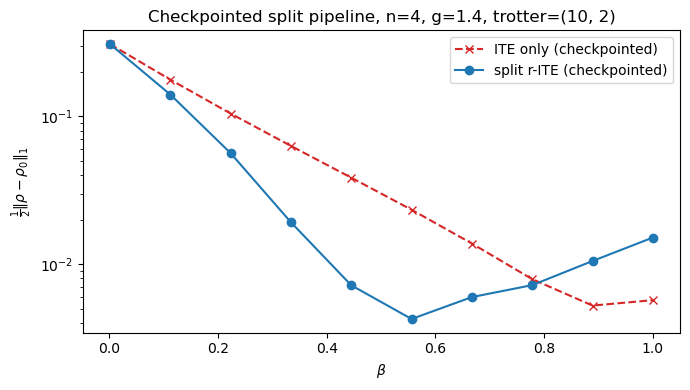

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(betas, tr_i, '--x', color='tab:red', mfc='none', label='ITE only (checkpointed)')
plt.plot(betas, tr_r, '-o', color='tab:blue', label='split r-ITE (checkpointed)')
plt.xlabel(r'$\beta$')
plt.yscale('log')
plt.ylabel(r'$\frac{1}{2}\|\rho-\rho_0\|_1$')
plt.title(f'Checkpointed split pipeline, n={n}, g={g}, trotter={trotter}')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:

save_name = f"data/checkpointed_run_n{n}_g{g}_steps{trotter[0]}_order{trotter[1]}_noise{noise:g}.npz"
np.savez_compressed(
    save_name,
    rho_ite=rho_ite,
    rho_rite=rho_rite,
    p_ite=p_ite,
    meta=np.array(meta, dtype=object),
    Hs=np.array(Hs, dtype=object),
    Hmat=Hmat,
    ground_rho=ground_rho,
    betas=betas,
    tr_i=tr_i,
    tr_r=tr_r,
    params=np.array({
        'n': n,
        'g': g,
        'J': J,
        'trotter': trotter,
        'rte_samples': rte_samples,
        'batch_size': batch_size,
        'noise': noise,
    }, dtype=object),
)
print(f"saved: {save_name}")


saved: data/checkpointed_run_n4_g1.4_steps10_order2_noise0.0001.npz


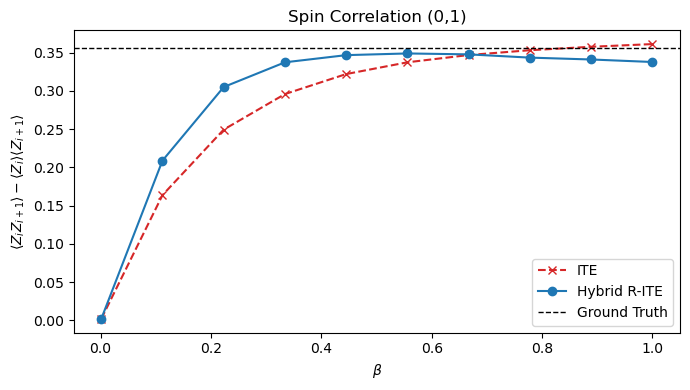

loaded: data/checkpointed_run_n4_g1.4_steps10_order2_noise0.0001.npz


In [51]:
# Load saved run and plot spin correlation (from paper/data/...)
load_name = save_name if 'save_name' in globals() else f"data/checkpointed_run_n{n}_g{g}_steps{trotter[0]}_order{trotter[1]}_noise{noise:g}.npz"
D = np.load(load_name, allow_pickle=True)

betas_l = D['betas']
rho_i_l = D['rho_ite']
rho_r_l = D['rho_rite']

def _obs(pauli):
    return Operator.from_label(pauli[::-1]).data

def _ex(rho, pauli):
    return np.trace(np.asarray(rho, dtype=complex) @ _obs(pauli))

def spin_cov_zz(rho, i, j):
    p = ['I'] * n
    p[i] = p[j] = 'Z'; zzi = _ex(rho, ''.join(p))
    p = ['I'] * n
    p[i] = 'Z'; zi = _ex(rho, ''.join(p))
    p = ['I'] * n
    p[j] = 'Z'; zip1 = _ex(rho, ''.join(p))
    return np.real(zzi - zi * zip1)

spin_i = 0
spin_j = 1

cov_i = np.array([spin_cov_zz(r, spin_i, spin_j) for r in rho_i_l])
cov_r = np.array([spin_cov_zz(r, spin_i, spin_j) for r in rho_r_l])
cov_g = spin_cov_zz(ground_rho, spin_i, spin_j)

plt.figure(figsize=(7, 4))
plt.plot(betas_l, cov_i, '--x', color='tab:red', mfc='none', label='ITE')
plt.plot(betas_l, cov_r, '-o', color='tab:blue', label='Hybrid R-ITE')
plt.axhline(cov_g, color='black', linestyle='--', linewidth=1, label='Ground Truth')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\langle Z_i Z_{i+1}\rangle-\langle Z_i\rangle\langle Z_{i+1}\rangle$')
plt.title(f"Spin Correlation ({spin_i},{spin_j})")
plt.legend()
plt.tight_layout()
plt.show()

print(f'loaded: {load_name}')

In [ ]:
n = 10
g = 1.4
J = 1.0
betas = np.linspace(1e-3, 1.0, 10)
trotter = (100, 2)
rte_samples = 1024
batch_size = 128
noise = 0

Hs = spin_chain_H_terms(n, J=J, g=g)
Hmat = H_to_matrix(Hs)
w, V = np.linalg.eigh(Hmat)
ground_rho = outer(V[:, 0])
Delta = w[1] - w[0]
Tmin = lambda b, p : b**(1+1/p)*np.exp(2*b*Delta/p)
print(Tmin(betas[-1], trotter[1]), trotter[0])

2.663927389149363 100


In [8]:
# Noise sweep with redundant saving: per-beta files + one aggregate file per noise
noise_levels = [1e-6, 1e-5, 1e-4]
run_stamp = time.strftime('%Y%m%d_%H%M%S')
save_root = os.path.join('.', 'data', run_stamp)
os.makedirs(save_root, exist_ok=True)
print(f'saving to: {save_root}')

noise_sweep_results = {}
for p in noise_levels:
    print(f'noise={p:.0e}')
    rho_ite_n, rho_rite_n, p_ite_n, meta_n = run_split_over_betas(
        Hs,
        n,
        betas,
        trotter=trotter,
        rte_samples=rte_samples,
        noise_model=make_noise_model(p),
        batch_size=batch_size,
        sampler=lambda beta, Delta: sample_sdelta(Delta),
        Delta=Delta,
        save_dir=save_root,
        noise_strength=p,
    )

    noise_sweep_results[p] = dict(rho_ite=rho_ite_n, rho_rite=rho_rite_n, p_ite=p_ite_n, meta=meta_n)

    agg_name = (
        f"noise_n{n}_g{g:g}_J{J:g}_noise{p:.0e}_steps{trotter[0]}_order{trotter[1]}_"
        f"rte{rte_samples}_bs{batch_size}_{run_stamp}.npz"
    )
    np.savez_compressed(
        os.path.join(save_root, agg_name),
        rho_ite=rho_ite_n,
        rho_rite=rho_rite_n,
        p_ite=p_ite_n,
        meta=np.array(meta_n, dtype=object),
        Hs=np.array(Hs, dtype=object),
        Hmat=Hmat,
        ground_rho=ground_rho,
        betas=betas,
        Delta=Delta,
        noise_strength=p,
        params=np.array({
            'n': n,
            'g': g,
            'J': J,
            'trotter': trotter,
            'rte_samples': rte_samples,
            'batch_size': batch_size,
        }, dtype=object),
    )

print('done noise sweep + saves')

saving to: ./data/20260520_232122
noise=1e-06


split sweep:   0%|          | 0/10 [00:00<?, ?beta/s]

beta 1/10 ITE:   0%|          | 0/3800 [00:00<?, ?batch/s]

beta 1/10 RTE:   0%|          | 0/8 [00:00<?, ?batch/s]

beta 2/10 ITE:   0%|          | 0/3800 [00:00<?, ?batch/s]

KeyboardInterrupt: 